# Cosine Similarity & Masked Word Residuals with a Pre-trained LLM

This notebook:
1. Loads a pre-trained transformer (BERT) once
2. Extracts **content words** (nouns, verbs, adjectives, adverbs) from a sentence
3. Computes **cosine similarity** between the contextual embeddings of those words
4. For each content word, **masks it** and shows the top predicted replacements with their probability scores (residuals)

## 1. Install dependencies (run once)

In [1]:
# Uncomment the lines below if packages are not yet installed
# !pip install transformers torch spacy seaborn matplotlib ipywidgets scikit-learn
# !python -m spacy download nl_core_news_sm

In [3]:
#!python -m spacy download nl_core_news_sm

## 2. Imports

In [1]:
import torch
import numpy as np
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from transformers import BertTokenizer, BertModel, BertForMaskedLM
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display
import pandas as pd

warnings.filterwarnings('ignore')

# Load Dutch spaCy model for POS tagging
nlp = spacy.load('nl_core_news_sm')

print('All imports successful.')

/opt/anaconda3/envs/hltenv/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


All imports successful.


## 3. Load model & tokenizer (run once — slow, ~400 MB download)

In [2]:
#MODEL_NAME = 'bert-base-uncased'
MODEL_NAME = 'google-bert/bert-base-multilingual-uncased'

print(f'Loading tokenizer and models from "{MODEL_NAME}" ...')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
embed_model = BertModel.from_pretrained(MODEL_NAME)        # for contextual embeddings
mlm_model   = BertForMaskedLM.from_pretrained(MODEL_NAME) # for masked predictions

embed_model.eval()
mlm_model.eval()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embed_model.to(DEVICE)
mlm_model.to(DEVICE)

print(f'Models loaded on {DEVICE}.')

Loading tokenizer and models from "google-bert/bert-base-multilingual-uncased" ...


Some weights of the model checkpoint at google-bert/bert-base-multilingual-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Models loaded on cpu.


## 4. Helper functions

In [3]:
# Universal POS tags that count as content words (language-independent)
CONTENT_UPOS = {'NOUN', 'VERB', 'ADJ', 'ADV'}


def get_content_words(sentence: str) -> list[tuple[str, str, int]]:
    """Return (word, upos_tag, token_index) for every content word using spaCy."""
    doc = nlp(sentence)
    return [(tok.text, tok.pos_, tok.i)
            for tok in doc
            if tok.pos_ in CONTENT_UPOS]


def get_contextual_embeddings(sentence: str) -> tuple[list[str], np.ndarray]:
    """
    Tokenize with BERT and return:
      - wordpiece tokens (without [CLS]/[SEP])
      - embedding matrix (n_tokens x hidden_size)
    """
    enc = tokenizer(sentence, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = embed_model(**enc)
    embeddings = out.last_hidden_state[0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0].tolist())
    return tokens[1:-1], embeddings[1:-1]


def word_to_bert_span(bert_tokens: list[str], word: str, start_hint: int = 0) -> tuple[int, int]:
    """
    Find the span [start, end) of `word` in bert_tokens.
    BERT may split a word into multiple wordpieces; we reconstruct and match.
    `start_hint` lets us skip earlier occurrences of the same word.
    """
    target = word.lower()
    for i in range(start_hint, len(bert_tokens)):
        reconstructed = ''
        for j in range(i, len(bert_tokens)):
            piece = bert_tokens[j].lstrip('#')
            reconstructed += piece
            if reconstructed == target:
                return i, j + 1
            if not target.startswith(reconstructed):
                break
    return -1, -1


def word_embedding(bert_tokens: list[str], embeddings: np.ndarray,
                   word: str, occurrence: int = 0) -> np.ndarray:
    """Average the embeddings of all wordpieces that make up `word`."""
    hint = 0
    for _ in range(occurrence + 1):
        start, end = word_to_bert_span(bert_tokens, word, hint)
        hint = end if end > 0 else len(bert_tokens)
    if start == -1:
        return None
    return embeddings[start:end].mean(axis=0)


def masked_predictions(sentence: str, target_word: str,
                       top_k: int = 10) -> list[tuple[str, float]]:
    """
    Replace the first occurrence of `target_word` with [MASK] and return
    the top-k predicted tokens with their softmax probabilities.
    """
    tokens = tokenizer.tokenize(sentence)
    target_pieces = tokenizer.tokenize(target_word)

    mask_positions = []
    for i in range(len(tokens) - len(target_pieces) + 1):
        if tokens[i:i+len(target_pieces)] == target_pieces:
            mask_positions = list(range(i, i + len(target_pieces)))
            break

    if not mask_positions:
        return []

    masked_tokens = (tokens[:mask_positions[0]]
                     + ['[MASK]'] * len(mask_positions)
                     + tokens[mask_positions[-1]+1:])
    input_ids = torch.tensor(
        [tokenizer.convert_tokens_to_ids(['[CLS]'] + masked_tokens + ['[SEP]'])]
    ).to(DEVICE)

    with torch.no_grad():
        logits = mlm_model(input_ids).logits

    adjusted_positions = [p + 1 for p in mask_positions]
    avg_logits = logits[0, adjusted_positions].mean(dim=0)
    probs = torch.softmax(avg_logits, dim=-1).cpu().numpy()

    top_indices = probs.argsort()[::-1][:top_k]
    return [(tokenizer.convert_ids_to_tokens([idx])[0], float(probs[idx]))
            for idx in top_indices]


print('Helper functions defined.')

Helper functions defined.


## 5. Main analysis function

In [4]:
def analyse_sentence(sentence: str, top_k: int = 10, figsize_base: int = 5):
    """
    Full pipeline:
      - Extract content words
      - Compute pairwise cosine similarity heatmap
      - For each content word show masked residual bar chart
    """
    print(f'Sentence: "{sentence}"\n')

    # --- Content words ---
    content = get_content_words(sentence)
    if not content:
        print('No content words found.')
        return

    words = [w for w, t, i in content]
    print(f'Content words: {[(w, t) for w, t, i in content]}\n')

    # --- Contextual embeddings ---
    bert_tokens, embeddings = get_contextual_embeddings(sentence)

    # Track occurrence count for repeated words
    occurrence_count = {}
    word_vecs = []
    valid_words = []
    for w, t, i in content:
        occ = occurrence_count.get(w.lower(), 0)
        vec = word_embedding(bert_tokens, embeddings, w, occ)
        occurrence_count[w.lower()] = occ + 1
        if vec is not None:
            word_vecs.append(vec)
            valid_words.append(w)

    if len(valid_words) < 2:
        print('Need at least 2 content words for a similarity matrix.')
    else:
        # ---- Cosine similarity heatmap ----
        matrix = cosine_similarity(word_vecs)
        df_sim = pd.DataFrame(matrix, index=valid_words, columns=valid_words)

        print('=== Cosine Similarity Matrix ===')
        display(df_sim.round(3))

        fig_size = max(figsize_base, len(valid_words))
        fig, ax = plt.subplots(figsize=(fig_size, fig_size - 1))
        sns.heatmap(df_sim, annot=True, fmt='.3f', cmap='RdYlGn',
                    vmin=-1, vmax=1, linewidths=0.5, ax=ax,
                    cbar_kws={'label': 'Cosine Similarity'})
        ax.set_title('Contextual Cosine Similarity between Content Words', pad=12)
        plt.tight_layout()
        plt.show()

    # ---- Masked residuals per word ----
    print('\n=== Masked-Word Residuals ===')
    n_words = len(valid_words)
    ncols = min(3, n_words)
    nrows = (n_words + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4 * nrows),
                             squeeze=False)

    for idx, word in enumerate(valid_words):
        preds = masked_predictions(sentence, word, top_k=top_k)
        ax = axes[idx // ncols][idx % ncols]
        if preds:
            labels = [p[0] for p in preds]
            scores = [p[1] for p in preds]
            colors = ['steelblue' if lbl == word.lower() else 'lightgray'
                      for lbl in labels]
            bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1])
            ax.set_xlabel('Probability')
            ax.set_title(f'[MASK] ← "{word}"')
            ax.set_xlim(0, max(scores) * 1.15)
            for bar, score in zip(bars, scores[::-1]):
                ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                        f'{score:.4f}', va='center', fontsize=8)
        else:
            ax.text(0.5, 0.5, f'Could not mask "{word}"',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'"{word}"')

    # Hide unused subplots
    for idx in range(n_words, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    plt.suptitle('Top Predictions When Each Content Word is Masked\n'
                 '(blue bar = the original word)', y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()

    # ---- Tabular residuals ----
    print('\n=== Residual Tables ===')
    for word in valid_words:
        preds = masked_predictions(sentence, word, top_k=top_k)
        df = pd.DataFrame(preds, columns=['predicted_token', 'probability'])
        # rank of the original word
        rank = next((i + 1 for i, (t, _) in enumerate(preds)
                     if t == word.lower()), None)
        rank_str = f'rank {rank}' if rank else 'not in top-k'
        print(f'\n"{word}" → original word is {rank_str} among predictions:')
        display(df.round(5))


print('analyse_sentence() defined.')

analyse_sentence() defined.


## 6. Run the analysis

Change `SENTENCE` to any sentence you like, then re-run this cell.

Sentence: "De fietser fietste met zijn fiets over het fietspad naar de fietswinkel voor een fietsbel."

Content words: [('fietser', 'NOUN'), ('fietste', 'VERB'), ('fiets', 'NOUN'), ('fietspad', 'NOUN'), ('fietswinkel', 'NOUN'), ('fietsbel', 'NOUN')]

=== Cosine Similarity Matrix ===


,fietser,fietste,fiets,fietspad,fietswinkel,fietsbel
fietser,1.000,0.706,0.677,0.745,0.766,0.740
fietste,0.706,1.000,0.949,0.769,0.759,0.790
fiets,0.677,0.949,1.000,0.751,0.744,0.783
fietspad,0.745,0.769,0.751,1.000,0.932,0.879
fietswinkel,0.766,0.759,0.744,0.932,1.000,0.915
fietsbel,0.740,0.790,0.783,0.879,0.915,1.000


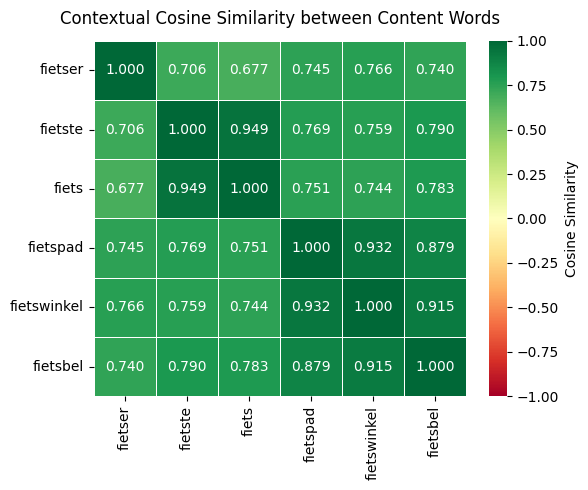


=== Masked-Word Residuals ===


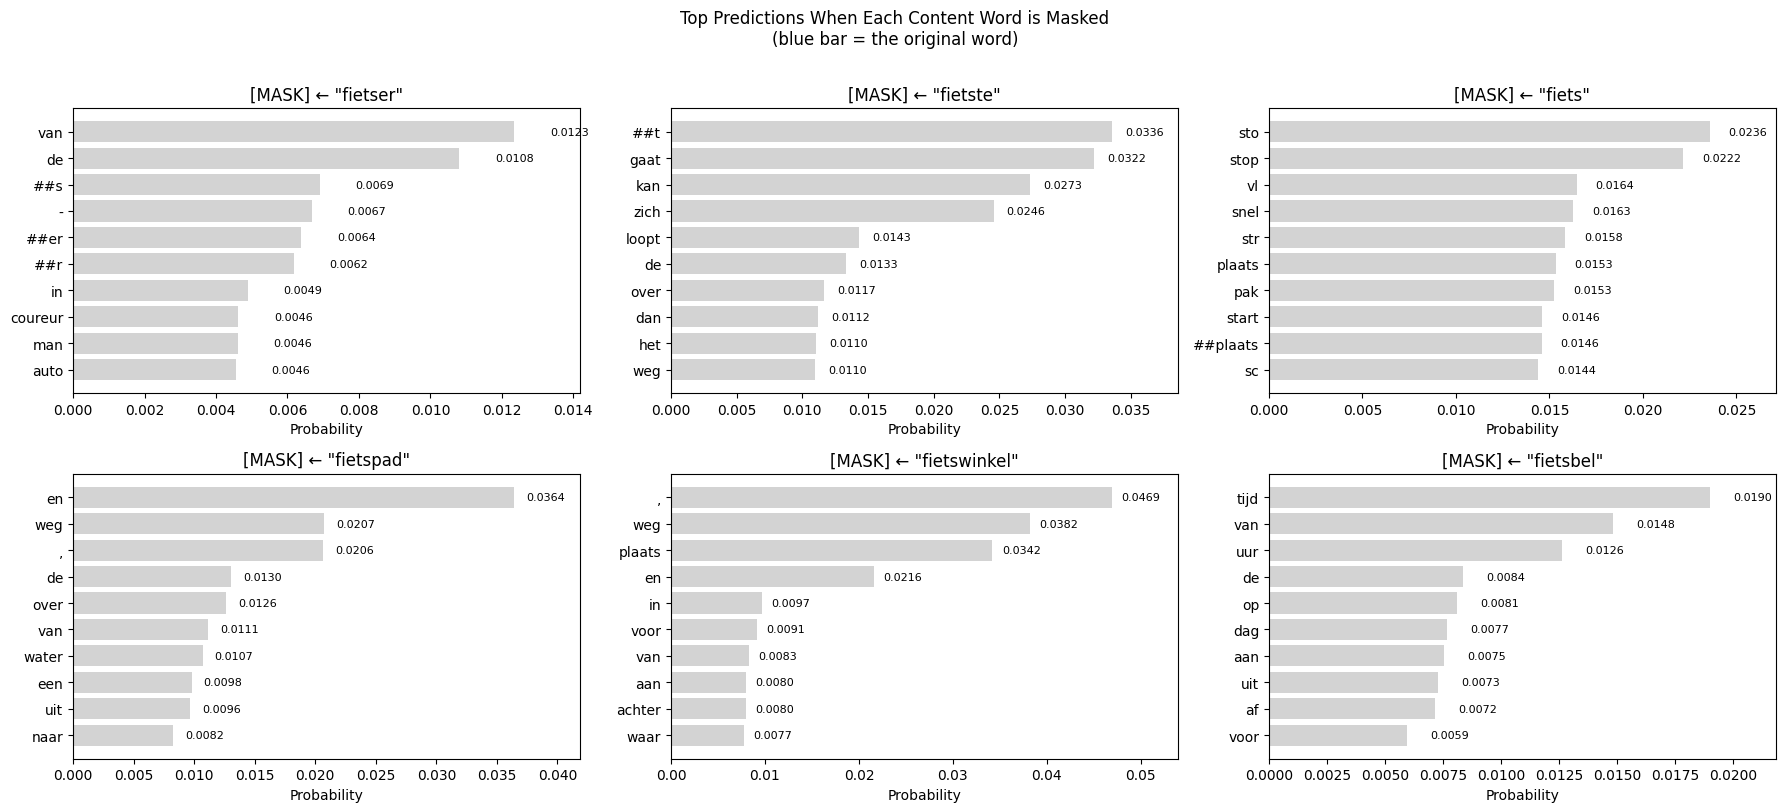


=== Residual Tables ===

"fietser" → original word is not in top-k among predictions:


,predicted_token,probability
0,van,0.01234
1,de,0.01081
2,##s,0.00690
3,-,0.00668
4,##er,0.00639
5,##r,0.00618
6,in,0.00489
7,coureur,0.00463
8,man,0.00461
9,auto,0.00456



"fietste" → original word is not in top-k among predictions:


,predicted_token,probability
0,##t,0.03357
1,gaat,0.03221
2,kan,0.02731
3,zich,0.02456
4,loopt,0.01431
5,de,0.01334
6,over,0.01165
7,dan,0.01120
8,het,0.01101
9,weg,0.01098



"fiets" → original word is not in top-k among predictions:


...

,predicted_token,probability
0,en,0.03641
1,weg,0.02074
2,",",0.02061
3,de,0.01301
4,over,0.01263
5,van,0.01111
6,water,0.01069
7,een,0.00979
8,uit,0.00962
9,naar,0.00824



"fietswinkel" → original word is not in top-k among predictions:


,predicted_token,probability
0,",",0.04692
1,weg,0.03819
2,plaats,0.03420
3,en,0.02160
4,in,0.00970
5,voor,0.00912
6,van,0.00833
7,aan,0.00802
8,achter,0.00799
9,waar,0.00772



"fietsbel" → original word is not in top-k among predictions:


,predicted_token,probability
0,tijd,0.01899
1,van,0.01482
2,uur,0.01261
3,de,0.00836
4,op,0.00809
5,dag,0.00767
6,aan,0.00753
7,uit,0.00728
8,af,0.00716
9,voor,0.00594


In [5]:
SENTENCE = "The quick brown fox jumps over the lazy dog."
SENTENCE = "De fietser fietste met zijn fiets over het fietspad naar de fietswinkel voor een fietsbel."
TOP_K    = 10   # how many predicted replacements to show per masked word

analyse_sentence(SENTENCE, top_k=TOP_K)

## 7. Interactive widget (optional)

If you have `ipywidgets` installed and are running in a full Jupyter environment (not VS Code's basic kernel), this cell gives you a live text box.

In [6]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    text_input = widgets.Text(
        value='The scientist carefully examined the ancient fossil.',
        description='Sentence:',
        layout=widgets.Layout(width='70%')
    )
    top_k_input = widgets.IntSlider(
        value=10, min=3, max=20, step=1, description='Top-k:'
    )
    run_button = widgets.Button(description='Analyse', button_style='primary')
    output = widgets.Output()

    def on_click(b):
        with output:
            clear_output(wait=True)
            analyse_sentence(text_input.value, top_k=top_k_input.value)

    run_button.on_click(on_click)
    display(widgets.VBox([text_input, top_k_input, run_button, output]))

except ImportError:
    print('ipywidgets not available — use cell 6 directly.')

## Trials

Sentence: "De fietswinkel fietspad met zijn fietsbel over het fiets naar de fietste voor een fietser."

Content words: [('fietswinkel', 'NOUN'), ('fietspad', 'VERB'), ('fietsbel', 'NOUN'), ('fiets', 'NOUN'), ('fietste', 'ADJ'), ('fietser', 'NOUN')]

=== Cosine Similarity Matrix ===


,fietswinkel,fietspad,fietsbel,fiets,fietste,fietser
fietswinkel,1.000,0.926,0.877,0.960,0.845,0.717
fietspad,0.926,1.000,0.871,0.895,0.827,0.734
fietsbel,0.877,0.871,1.000,0.850,0.863,0.719
fiets,0.960,0.895,0.850,1.000,0.823,0.734
fietste,0.845,0.827,0.863,0.823,1.000,0.718
fietser,0.717,0.734,0.719,0.734,0.718,1.000


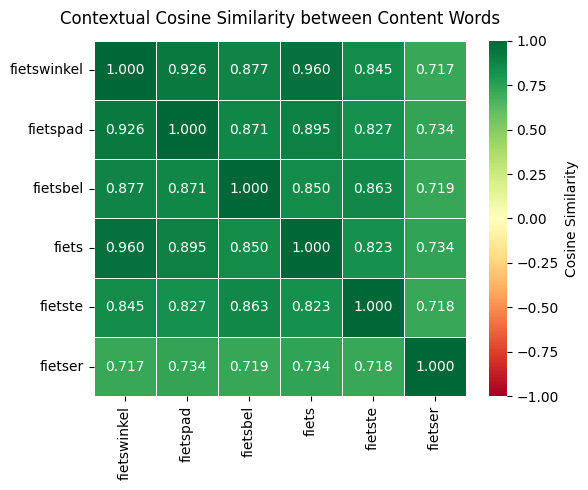


=== Masked-Word Residuals ===


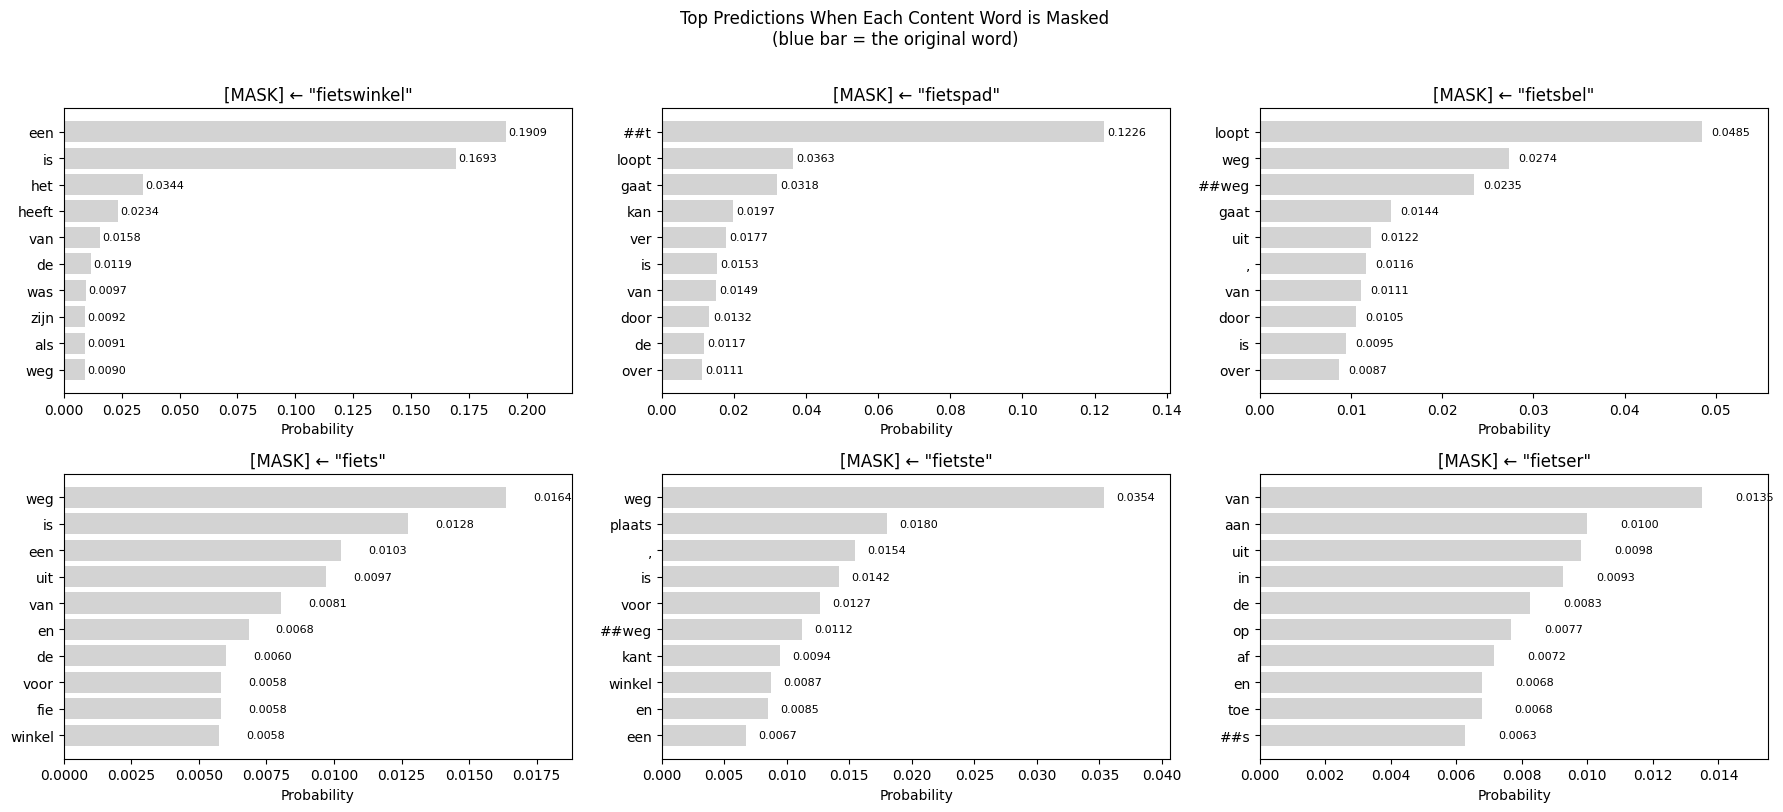


=== Residual Tables ===

"fietswinkel" → original word is not in top-k among predictions:


,predicted_token,probability
0,een,0.19091
1,is,0.16930
2,het,0.03436
3,heeft,0.02338
4,van,0.01579
5,de,0.01191
6,was,0.00968
7,zijn,0.00924
8,als,0.00912
9,weg,0.00904



"fietspad" → original word is not in top-k among predictions:


,predicted_token,probability
0,##t,0.12263
1,loopt,0.03629
2,gaat,0.03183
3,kan,0.01974
4,ver,0.01769
5,is,0.01528
6,van,0.01493
7,door,0.01321
8,de,0.01170
9,over,0.01112



"fietsbel" → original word is not in top-k among predictions:


...

,predicted_token,probability
0,weg,0.01637
1,is,0.01276
2,een,0.01027
3,uit,0.00971
4,van,0.00805
5,en,0.00684
6,de,0.00601
7,voor,0.00583
8,fie,0.00583
9,winkel,0.00576



"fietste" → original word is not in top-k among predictions:


,predicted_token,probability
0,weg,0.03538
1,plaats,0.01799
2,",",0.01544
3,is,0.01417
4,voor,0.01266
5,##weg,0.01121
6,kant,0.00942
7,winkel,0.00873
8,en,0.00849
9,een,0.00674



"fietser" → original word is not in top-k among predictions:


,predicted_token,probability
0,van,0.01350
1,aan,0.00999
2,uit,0.00981
3,in,0.00927
4,de,0.00825
5,op,0.00767
6,af,0.00716
7,en,0.00678
8,toe,0.00677
9,##s,0.00627


In [7]:
SENTENCE = "De fietswinkel fietspad met zijn fietsbel over het fiets naar de fietste voor een fietser."
TOP_K    = 10   # how many predicted replacements to show per masked word

analyse_sentence(SENTENCE, top_k=TOP_K)